# Random Forest (5/6) — Feature Importance

### The idea in one sentence
> A feature is important if the splits that use it **remove a lot of impurity**. A random forest adds this up in
> every tree and **averages over the trees**.

### In this notebook
1. How one tree calculates importance: a **worked example by hand** (and it matches scikit-learn)
2. The same calculation as a small function, on a bigger tree
3. Random forest importance = **average** of the trees' importances
4. A picture of importance: which **pixels** matter for recognising digits
5. ⚠️ The bias of impurity importance, and **permutation importance** as the alternative

> 📖 Theory: [`theory.md`](theory.md) §12 · ✍️ = core code to learn · 🎨 = visualization only (collapsed)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
from sklearn.datasets import make_classification, load_digits
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

## 1. A worked example with 5 rows

Recall the **Gini impurity** of a node: $G = 1 - \sum_k p_k^2$ (0 = pure, 0.5 = a 50/50 mix of two classes).

The **importance** of a split at node $t$ is the weighted impurity decrease:

$$\Delta(t) = \frac{N_t}{N}\Big(G_t - \frac{N_{L}}{N_t}G_{L} - \frac{N_{R}}{N_t}G_{R}\Big)
= \frac{N_t}{N}G_t - \frac{N_L}{N}G_L - \frac{N_R}{N}G_R$$

($N$ = rows in the whole tree, $N_t$ = rows reaching the node, $L$/$R$ = left/right child.)
A feature's importance = the sum of $\Delta(t)$ over all nodes that split on it, then **normalised** to sum to 1.

In [2]:
X, y = make_classification(n_samples=5, n_classes=2, n_features=2, n_informative=2, n_redundant=0,
                           random_state=0)
pd.DataFrame(X, columns=['f0', 'f1']).assign(target=y).round(2)

,f0,f1,target
0,0.96,-0.12,0
1,1.06,0.69,1
2,-0.56,0.08,0
3,-1.19,-1.66,1
4,-0.39,1.38,0


> ✍️ **Core code: learn this.** Fit a tree and ask scikit-learn for the importances.

In [3]:
clf = DecisionTreeClassifier(random_state=0).fit(X, y)
print("sklearn feature_importances_:", clf.feature_importances_)

sklearn feature_importances_: [0.625 0.375]


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

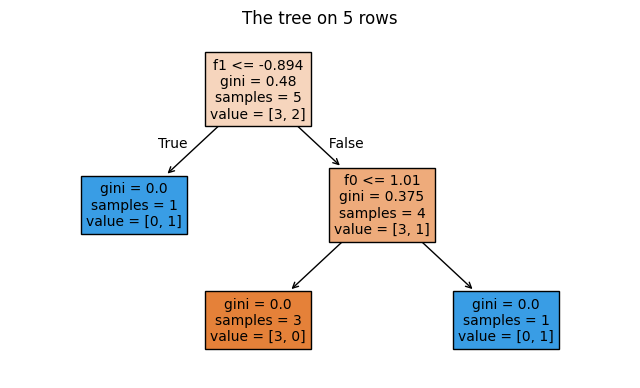

In [4]:
plt.figure(figsize=(8, 4.5))
plot_tree(clf, feature_names=['f0', 'f1'], filled=True, fontsize=10)
plt.title('The tree on 5 rows')
plt.show()

**By hand** (read the numbers from the boxes above):

| Node | Splits on | $N_t$ | Gini $G_t$ | Children ($N$, Gini) | $\Delta(t) = \frac{N_t}{N}G_t - \frac{N_L}{N}G_L - \frac{N_R}{N}G_R$ |
|---|---|---|---|---|---|
| root | `f1` | 5 | 0.48 | left (1, 0.0), right (4, 0.375) | $\frac55 0.48 - \frac15 0 - \frac45 0.375 = 0.48 - 0.30 = $ **0.18** |
| right child | `f0` | 4 | 0.375 | (3, 0.0), (1, 0.0) | $\frac45 0.375 - 0 - 0 = $ **0.30** |

Total decrease = 0.18 + 0.30 = 0.48. Normalise:
- `f0` = 0.30 / 0.48 = **0.625**
- `f1` = 0.18 / 0.48 = **0.375**

Exactly what scikit-learn printed. Notice: `f1` is used **first** (at the root), but `f0` gets the **higher**
importance, because its split removed more impurity (0.30 vs 0.18). Importance is about *how much a split helps*,
not about *where* it sits in the tree.

## 2. The same calculation as a function

A fitted tree stores everything we need in `clf.tree_`: the feature of each node, its impurity, the number of
(weighted) samples, and its children. Let us check our formula on a bigger tree (15 rows).

> ✍️ **Core code: learn this.** Feature importance from scratch.

In [5]:
def tree_importance(clf):
    t = clf.tree_
    N = t.weighted_n_node_samples
    imp = np.zeros(t.n_features)
    for node in range(t.node_count):
        left, right = t.children_left[node], t.children_right[node]
        if left == -1:                       # a leaf: no split, no contribution
            continue
        decrease = N[node] * t.impurity[node] - N[left] * t.impurity[left] - N[right] * t.impurity[right]
        imp[t.feature[node]] += decrease / N[0]
    return imp / imp.sum()                   # normalise to sum to 1

X15, y15 = make_classification(n_samples=15, n_classes=2, n_features=2, n_informative=2, n_redundant=0,
                               random_state=0)
clf15 = DecisionTreeClassifier(random_state=0).fit(X15, y15)
print("our function :", tree_importance(clf15).round(4))
print("sklearn      :", clf15.feature_importances_.round(4))

our function : [0.4167 0.5833]
sklearn      : [0.4167 0.5833]


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

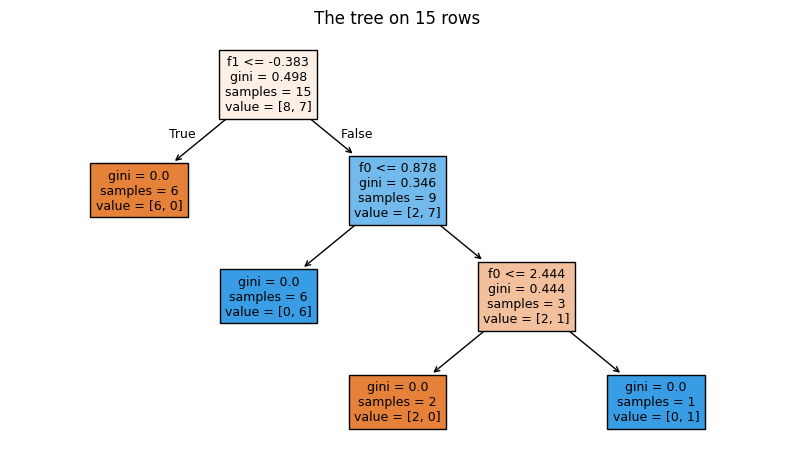

In [6]:
plt.figure(figsize=(10, 5.5))
plot_tree(clf15, feature_names=['f0', 'f1'], filled=True, fontsize=9)
plt.title('The tree on 15 rows')
plt.show()

Same result. You can verify it on the drawing: the root split on `f1` (15 rows, Gini 0.498) gives
$0.498 - \frac{9}{15}\cdot 0.346 \approx 0.290$; the two splits on `f0` give $\frac{9}{15}\cdot 0.346 -
\frac{3}{15}\cdot 0.444 \approx 0.119$ and $\frac{3}{15}\cdot 0.444 \approx 0.089$. So `f0` ≈ 0.208 and `f1` ≈ 0.290;
normalised: **0.417** and **0.583**.

## 3. Random forest importance = average over the trees

A random forest computes the (normalised) importance in **each tree**, then **averages** them.
With only 2 trees on the 5-row data it is easy to see:

> ✍️ **Core code: learn this.** The forest's importance is the mean of its trees' importances.

In [7]:
rf2 = RandomForestClassifier(n_estimators=2, random_state=0).fit(X, y)
for i, tree in enumerate(rf2.estimators_):
    print(f"tree {i}:", tree.feature_importances_)
print("average of the trees :", np.mean([t.feature_importances_ for t in rf2.estimators_], axis=0))
print("rf.feature_importances_:", rf2.feature_importances_)

tree 0: [1. 0.]
tree 1: [0. 1.]
average of the trees : [0.5 0.5]
rf.feature_importances_: [0.5 0.5]


Each tree saw a different bootstrap sample (and random features), so one tree relied only on `f0` and the other
only on `f1`. The forest's importance is their average.

The same holds for a big forest:

In [8]:
Xb, yb = make_classification(n_samples=500, n_features=6, n_informative=3, n_redundant=0, random_state=1)
rf_big = RandomForestClassifier(n_estimators=200, random_state=0).fit(Xb, yb)
avg = np.mean([t.feature_importances_ for t in rf_big.estimators_], axis=0)
print("average of 200 trees   :", avg.round(4))
print("rf.feature_importances_:", rf_big.feature_importances_.round(4))
print("identical?", np.allclose(avg / avg.sum(), rf_big.feature_importances_))

average of 200 trees   : [0.0549 0.0532 0.3041 0.0532 0.3888 0.1458]
rf.feature_importances_: [0.0549 0.0532 0.3041 0.0532 0.3888 0.1458]
identical? True


## 4. Which pixels matter? Feature importance on handwritten digits

`load_digits` has 1,797 images of handwritten digits (0–9). Each image is **8 × 8 pixels = 64 features**. Because the
features are pixels, we can draw the 64 importances **as an image** and *see* where the forest looks.

> ✍️ **Core code: learn this.** Train a forest on the 64 pixel features.

In [9]:
digits = load_digits()
Xd, yd = digits.data, digits.target
print("images:", digits.images.shape, "| features per image:", Xd.shape[1])

Xd_train, Xd_test, yd_train, yd_test = train_test_split(Xd, yd, test_size=0.25, random_state=42, stratify=yd)
rf_digits = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1).fit(Xd_train, yd_train)
print("test accuracy:", round(rf_digits.score(Xd_test, yd_test), 3))

importance_img = rf_digits.feature_importances_.reshape(8, 8)

images: (1797, 8, 8) | features per image: 64


test accuracy: 0.967


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

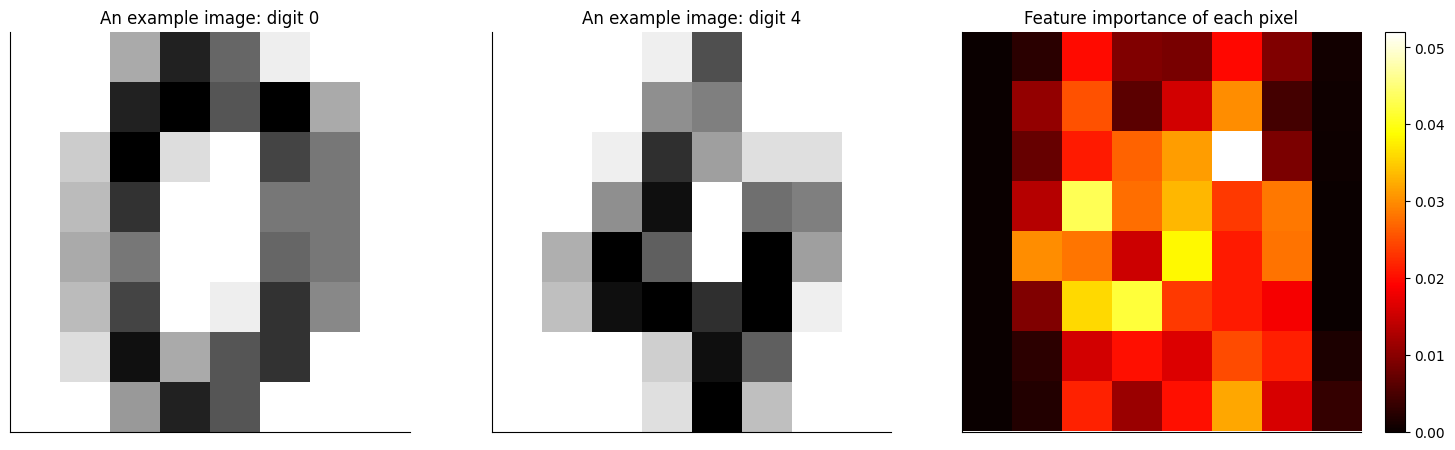

pixels with importance exactly 0: 4 of 64
always-blank pixels in the data : 3


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for k, ax in zip([0, 4], axes[:2]):
    idx = np.where(yd == k)[0][0]
    ax.imshow(digits.images[idx], cmap='gray_r')
    ax.set_title(f'An example image: digit {k}')
    ax.set_xticks([]); ax.set_yticks([])
im = axes[2].imshow(importance_img, cmap='hot')
axes[2].set_title('Feature importance of each pixel')
axes[2].set_xticks([]); axes[2].set_yticks([])
plt.colorbar(im, ax=axes[2], fraction=0.046)
plt.tight_layout()
plt.show()

zero = (rf_digits.feature_importances_ == 0).sum()
print(f"pixels with importance exactly 0: {zero} of 64")
print("always-blank pixels in the data :", (Xd.max(axis=0) == 0).sum())

**Reading the heatmap** (bright = important):
- The **left and right border columns are almost black**: those pixels are blank in nearly every image, so they
  cannot help tell digits apart. 4 pixels have importance exactly 0 (3 of them are blank in *every* image).
- The **brightest pixels are in the middle** of the image, where the strokes of different digits differ most
  (for example, the centre is empty for a 0 but filled for a 4 or an 8).

The forest reaches 0.967 test accuracy using pixels only, and the importance map shows *where* it looks.

> 🔧 The original notebook used the 28 × 28 MNIST `train.csv`, which is not in this repository. The 8 × 8
> `load_digits` images ship with scikit-learn and show the same idea.

## 5. ⚠️ A warning: impurity importance is biased

`feature_importances_` (also called **MDI**, *mean decrease in impurity*) is fast and free, but it has known
weaknesses:
- it is computed on the **training data**, so it also rewards splits that only fit noise;
- it **favours features with many unique values** (continuous numbers, IDs): they offer many possible split
  points, so by chance some split always looks useful.

**Experiment:** add two columns of pure random noise to the heart data, one continuous (`random_num`) and one with
only 3 values (`random_cat`). A good importance measure should give both (about) **zero**.

**Permutation importance** is the usual alternative: on **test** data, shuffle one column and measure how much the
accuracy drops. If the model really uses that feature, shuffling it hurts.

> ✍️ **Core code: learn this.** Add noise columns, then compare impurity importance with permutation importance.

In [11]:
heart = pd.read_csv('heart.csv')
Xh = heart.drop(columns='target')
yh = heart['target']

rng = np.random.default_rng(0)
Xh['random_num'] = rng.normal(size=len(Xh))           # continuous noise: many unique values
Xh['random_cat'] = rng.integers(0, 3, size=len(Xh))   # noise with only 3 values

Xh_train, Xh_test, yh_train, yh_test = train_test_split(Xh, yh, test_size=0.25, random_state=42)
rf_heart = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1).fit(Xh_train, yh_train)
print("test accuracy:", round(rf_heart.score(Xh_test, yh_test), 3))

mdi = pd.Series(rf_heart.feature_importances_, index=Xh.columns)
perm = permutation_importance(rf_heart, Xh_test, yh_test, n_repeats=30, random_state=42, n_jobs=-1)
perm_mean = pd.Series(perm.importances_mean, index=Xh.columns)

table = pd.DataFrame({'impurity (MDI)': mdi, 'MDI rank': mdi.rank(ascending=False).astype(int),
                      'permutation': perm_mean, 'perm. rank': perm_mean.rank(ascending=False).astype(int)})
table.sort_values('impurity (MDI)', ascending=False).round(3)

test accuracy: 0.842


,impurity (MDI),MDI rank,permutation,perm. rank
ca,0.141,1,0.038,2
oldpeak,0.109,2,0.019,3
cp,0.108,3,0.063,1
thalach,0.090,4,-0.006,11
thal,0.087,5,0.013,5
age,0.075,6,-0.006,12
exang,0.067,7,-0.000,9
random_num,0.067,8,0.004,7
trestbps,0.065,9,-0.002,10
chol,0.063,10,-0.011,15


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

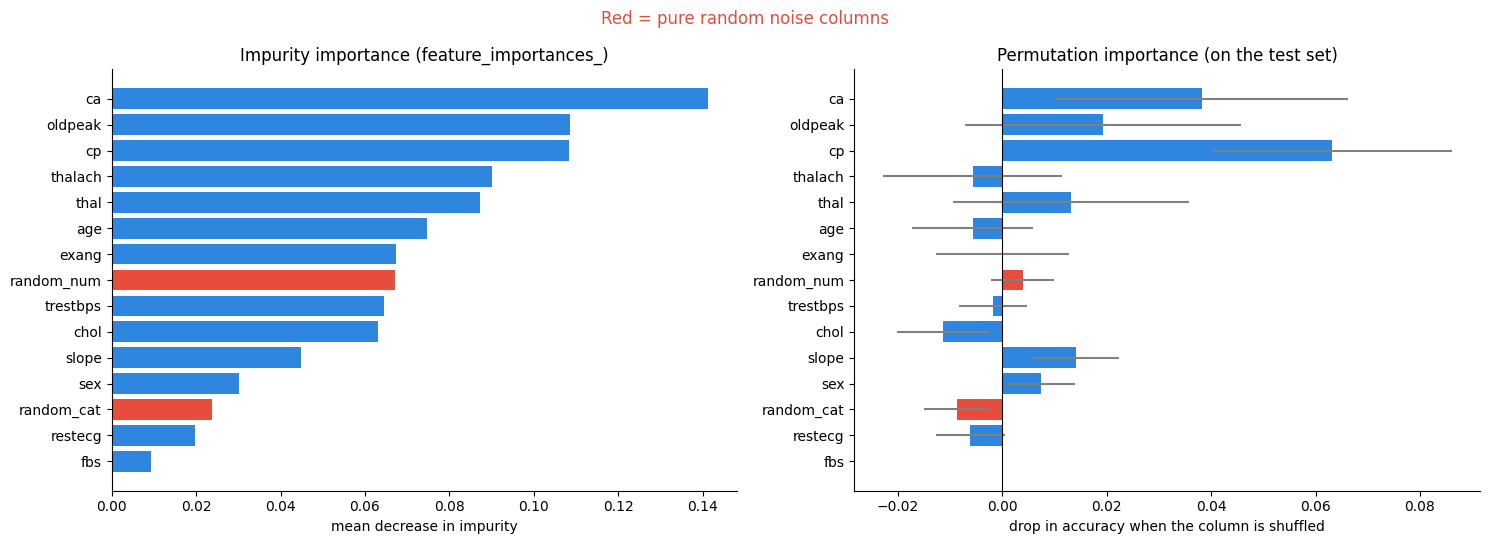

In [12]:
order = mdi.sort_values().index
colors = ['#e74c3c' if c.startswith('random') else '#2e86de' for c in order]
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
axes[0].barh(order, mdi[order], color=colors)
axes[0].set_title('Impurity importance (feature_importances_)')
axes[0].set_xlabel('mean decrease in impurity')
perm_std = pd.Series(perm.importances_std, index=Xh.columns)
axes[1].barh(order, perm_mean[order], xerr=perm_std[order], color=colors, ecolor='gray')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Permutation importance (on the test set)')
axes[1].set_xlabel('drop in accuracy when the column is shuffled')
fig.suptitle('Red = pure random noise columns', color='#e74c3c')
plt.tight_layout()
plt.show()

**What we see:**
- **Impurity importance is fooled by the continuous noise:** `random_num` gets 0.067 (rank 8 of 15), *more* than
  six real medical features (`trestbps`, `chol`, `slope`, `sex`, `restecg`, `fbs`).
- The 3-valued noise `random_cat` gets much less (0.024): fewer unique values = fewer chances for a lucky split.
  That is exactly the "many unique values" bias.
- **Permutation importance** gives both noise columns about **zero** (0.004 and −0.009, inside their error bars).
  Its top 3 (`cp`, `ca`, `oldpeak`) are the same three features MDI ranks highest.

> 🔎 **Honest note:** permutation importance is not perfect either. With only 76 test patients it is **noisy**
> (look at the wide error bars), and some real features (`thalach`, `age`, `chol`) also come out at or below 0.
> One reason: when features are **correlated**, shuffling one of them hurts little because the forest can use the
> others. Treat both methods as hints, not as exact truth.

| | Impurity importance (MDI) | Permutation importance |
|---|---|---|
| How | sum of impurity decreases in the trees | drop in score when a column is shuffled |
| Data | training data | any data, usually the **test** set |
| Cost | free (`feature_importances_`) | needs extra predictions (`n_repeats`) |
| Weakness | favours many-valued features, rewards over-fitting | noisy on small data; correlated features share importance |

---
## Key takeaways
- Importance of a split = **weighted impurity decrease** $\frac{N_t}{N}G_t - \frac{N_L}{N}G_L - \frac{N_R}{N}G_R$;
  sum per feature, then normalise to 1.
- Random forest importance = **average** of the trees' normalised importances.
- On image data, importances can be drawn as a picture: the forest looks at the **centre** strokes and (almost)
  never at the border pixels that are blank in nearly every image.
- Impurity importance is **biased** (training data, favours many-valued features). Check important decisions
  with **`permutation_importance`** on held-out data.

## 🧠 Quick check

<details><summary>1. A split is at the root but removes little impurity; another split deeper down removes a lot. Which feature gets more importance?</summary>

The one with the larger weighted impurity decrease. Position in the tree does not matter by itself (see the 5-row example: f0 wins although f1 is at the root).
</details>

<details><summary>2. How is a random forest's <code>feature_importances_</code> computed?</summary>

Each tree's normalised importances are averaged over all trees (then normalised again to sum to 1).
</details>

<details><summary>3. Why do the border pixels of the digits get zero importance?</summary>

They are blank (0) in (almost) every image, so splits on them cannot separate the digits.
</details>

<details><summary>4. Why can a column of random numbers get a sizeable impurity importance?</summary>

It has many unique values, so trees find (chance) splits on it that reduce impurity on the training data. Permutation importance on test data shows it does not really help.
</details>

➡️ **Next:** `06-hyperparameter-tuning.ipynb`: the main hyperparameters and GridSearchCV vs RandomizedSearchCV.